In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from my_nn.data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at a regression problem where the true function is z = x<sup>2</sup> + y<sup>2</sup>

In [3]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["regression"])
data_used = data[["x1","x2","regression"]].copy()

In [4]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [7]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="identity")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="identity")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="identity")
)

In [8]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="mse",
    metric=None,
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 29.1665 , mse 16.1651 -  Validation Loss: 16.8755, Validation mse 16.8755
Epoch 2 complete. Average Loss: 14.6274 , mse 12.9686 -  Validation Loss: 13.5964, Validation mse 13.5964
Epoch 3 complete. Average Loss: 12.0189 , mse 10.9618 -  Validation Loss: 11.4894, Validation mse 11.4894
Epoch 4 complete. Average Loss: 9.9546 , mse 8.6798 -  Validation Loss: 9.0643, Validation mse 9.0643
Epoch 5 complete. Average Loss: 7.8819 , mse 6.6945 -  Validation Loss: 7.0592, Validation mse 7.0592
Epoch 6 complete. Average Loss: 5.9480 , mse 5.1481 -  Validation Loss: 5.5705, Validation mse 5.5705
Epoch 7 complete. Average Loss: 4.5158 , mse 3.6669 -  Validation Loss: 3.9533, Validation mse 3.9533
Epoch 8 complete. Average Loss: 3.3355 , mse 3.0600 -  Validation Loss: 3.2679, Validation mse 3.2679
Epoch 9 complete. Average Loss: 2.6642 , mse 3.6656 -  Validation Loss: 3.8801, Validation mse 3.8801
Epoch 10 complete. Average Loss: 2.1981 , mse 1.9401 -  Validation Los

In [9]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="mse",
    metric=None,
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 29.9801 , mse 17.7768 -  Validation Loss: 17.4632, Validation mse 17.4632
Epoch 2 complete. Average Loss: 16.1416 , mse 14.4017 -  Validation Loss: 14.0479, Validation mse 14.0479
Epoch 3 complete. Average Loss: 13.4768 , mse 12.0168 -  Validation Loss: 11.6412, Validation mse 11.6412
Epoch 4 complete. Average Loss: 11.1222 , mse 9.9284 -  Validation Loss: 9.7390, Validation mse 9.7390
Epoch 5 complete. Average Loss: 9.3003 , mse 8.4346 -  Validation Loss: 8.4717, Validation mse 8.4717
Epoch 6 complete. Average Loss: 7.6510 , mse 7.2341 -  Validation Loss: 6.6624, Validation mse 6.6624
Epoch 7 complete. Average Loss: 6.1782 , mse 5.6756 -  Validation Loss: 5.6983, Validation mse 5.6983
Epoch 8 complete. Average Loss: 4.9116 , mse 4.2376 -  Validation Loss: 4.1451, Validation mse 4.1451
Epoch 9 complete. Average Loss: 3.8080 , mse 3.2650 -  Validation Loss: 2.9136, Validation mse 2.9136
Epoch 10 complete. Average Loss: 3.0527 , mse 2.5538 -  Validation Lo

In [10]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="mse",
    metric=None,
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 26.1483 , mse 3.0365 -  Validation Loss: 3.0835, Validation mse 3.0835
Epoch 2 complete. Average Loss: 1.3019 , mse 0.2823 -  Validation Loss: 0.2973, Validation mse 0.2973
Epoch 3 complete. Average Loss: 0.2492 , mse 0.2265 -  Validation Loss: 0.2460, Validation mse 0.2460
Epoch 4 complete. Average Loss: 0.1752 , mse 0.0904 -  Validation Loss: 0.0933, Validation mse 0.0933
Epoch 5 complete. Average Loss: 0.1591 , mse 0.1437 -  Validation Loss: 0.1546, Validation mse 0.1546
Epoch 6 complete. Average Loss: 0.1848 , mse 0.3977 -  Validation Loss: 0.4367, Validation mse 0.4367
Epoch 7 complete. Average Loss: 0.1063 , mse 0.0641 -  Validation Loss: 0.0643, Validation mse 0.0643
Epoch 8 complete. Average Loss: 0.1075 , mse 0.1059 -  Validation Loss: 0.1083, Validation mse 0.1083
Epoch 9 complete. Average Loss: 0.1107 , mse 0.1094 -  Validation Loss: 0.1195, Validation mse 0.1195
Epoch 10 complete. Average Loss: 0.0965 , mse 0.0574 -  Validation Loss: 0.0591, 

#### Let's look at the training history for each. Since we used MSE for loss, we don't need it separately graphed

##### First, standard gradient descent.

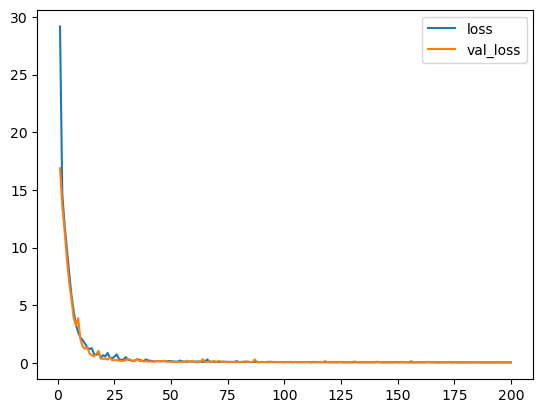

In [11]:
nn.plot_history(history_sgd, "loss", "val_loss")

##### Next, for using momentum

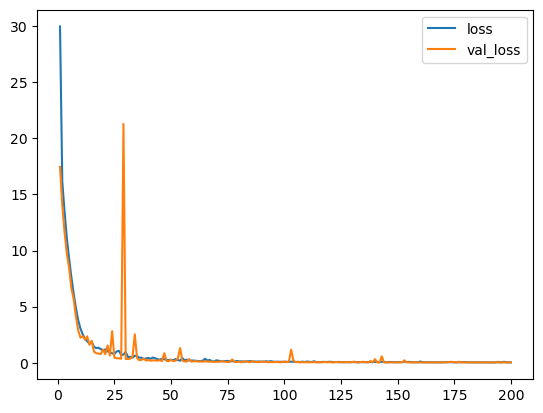

In [12]:
nn.plot_history(history_momentum, "loss", "val_loss")

##### Finally, for adam optimization

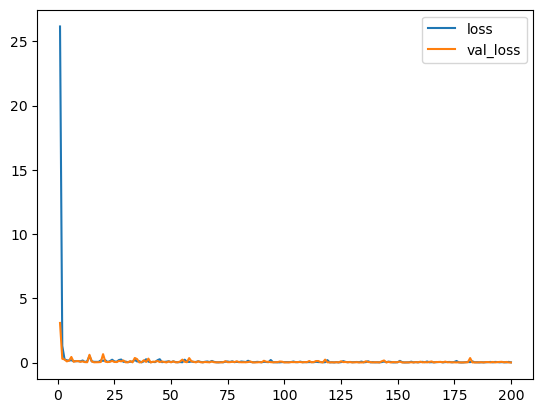

In [13]:
nn.plot_history(history_adam, "loss", "val_loss")

In [14]:
#### Next, let's see how they do on unseen data

In [26]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [27]:
mse_sgd = metrics.mse(y_test, y_pred_sgd)
mae_sgd = metrics.mae(y_test, y_pred_sgd)
r2_sgd = metrics.r2_score(y_test, y_pred_sgd)

mse_mom = metrics.mse(y_test, y_pred_momentum)
mae_mom = metrics.mae(y_test, y_pred_momentum)
r2_mom = metrics.r2_score(y_test, y_pred_momentum)

mse_adam = metrics.mse(y_test, y_pred_adam)
mae_adam = metrics.mae(y_test, y_pred_adam)
r2_adam = metrics.r2_score(y_test, y_pred_adam)

In [28]:
print("For standard gradient descent")
print("-----------------------------")
print(f"MSE: {mse_sgd: .6f}")
print(f"MAE: {mae_sgd: .6f}")
print(f"R2: {r2_sgd: .6f}")
print("")
print("For momentum")
print("------------")
print(f"MSE: {mse_mom: .6f}")
print(f"MAE: {mae_mom: .6f}")
print(f"R2 : {r2_mom: .6f}")
print("")
print("For adam optimization")
print("---------------------")
print(f"MSE: {mse_adam: .6f}")
print(f"MAE: {mae_adam: .6f}")
print(f"R2: {r2_adam: .6f}")

For standard gradient descent
-----------------------------
MSE:  0.049729
MAE:  0.171869
R2:  0.999562

For momentum
------------
MSE:  0.029020
MAE:  0.130194
R2 :  0.999742

For adam optimization
---------------------
MSE:  0.008937
MAE:  0.073755
R2:  0.999921


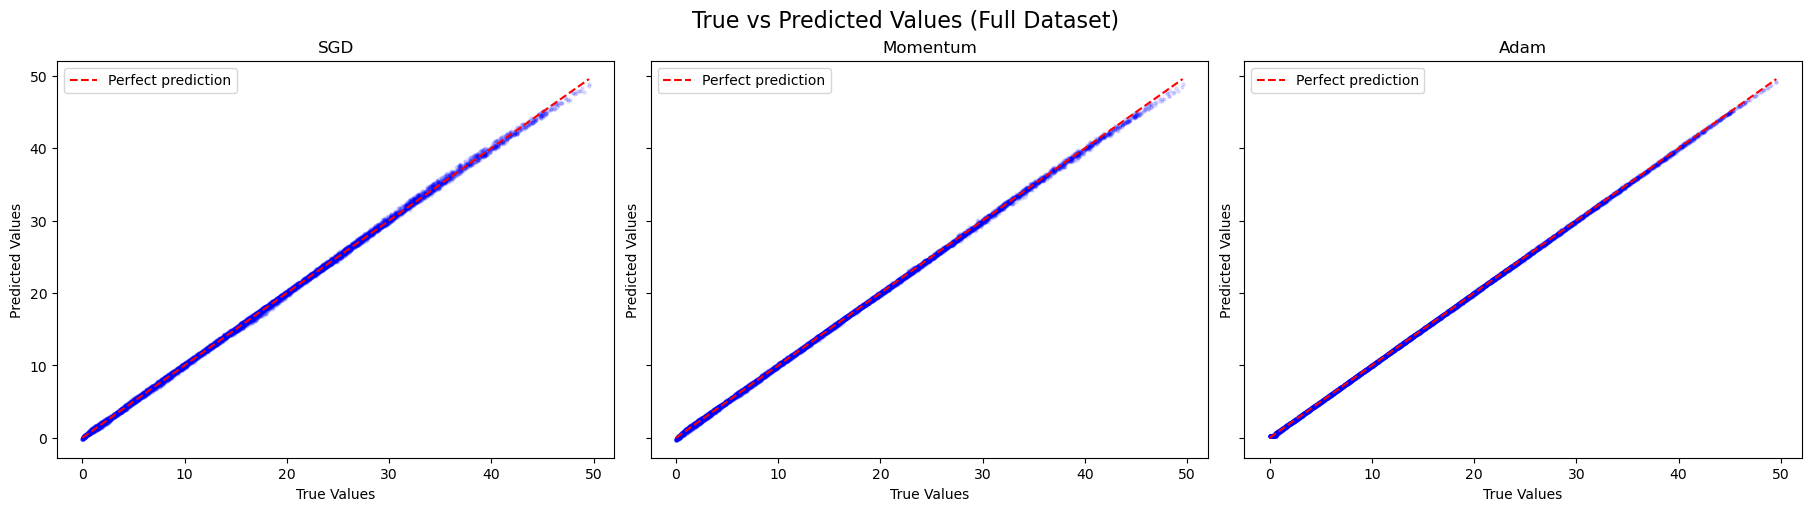

In [34]:


# Predict on full dataset
y_pred_sgd = model_sgd.predict(X)
y_pred_momentum = model_momentum.predict(X)
y_pred_adam = model_adam.predict(X)

optimizers = [
    ("SGD", y_pred_sgd),
    ("Momentum", y_pred_momentum),
    ("Adam", y_pred_adam)
]

# --- Determine global color scale ---
all_y_true = np.tile(y.flatten(), len(optimizers))
all_y_pred = np.concatenate([y_pred.flatten() for _, y_pred in optimizers])

counts, xedges, yedges = np.histogram2d(all_y_true, all_y_pred, bins=50)
vmin, vmax = counts[counts > 0].min(), counts.max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
x_line = np.linspace(y.min(), y.max(), 100)

for ax, (name, y_pred) in zip(axes, optimizers):
    ax.scatter(
        y.flatten(), y_pred.flatten(),
        alpha=0.1, s=5, c="blue"
    )
    ax.plot(x_line, x_line, "r--", label="Perfect prediction")
    ax.set_title(name)
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")
    ax.legend()

fig.suptitle("True vs Predicted Values (Full Dataset)", fontsize=16)
plt.show()


#### We can see how well the regression extends outside the [-5,5]<sup>2</sup> square.

In [ ]:
# create a bunch of points in [-7,7] x [-7,7]
x1 = np.linspace(-7, 7, 100)
x2 = np.linspace(-7, 7, 100)
X1_grid, X2_grid = np.meshgrid(x1, x2)
X_extrap = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
# compute y_true for that square using the same definition
y_extrap = X_extrap[:,0]**2 + X_extrap[:,1]**2 
# get predictions for the model on the extended square
y_pred_extrap_sgd = model_sgd.predict(X_extrap)
y_pred_extrap_mom = model_momentum.predict(X_extrap)
y_pred_extrap_adam = model_adam.predict(X_extrap)


In [49]:
print(f"For SGD on the extended square, MSE :{metrics.mse(y_pred_extrap_sgd, y_extrap) :.5f}")

For SGD on the extended square, MSE :8.08686


In [50]:
print(f"For momentum on the extended square, MSE :{metrics.mse(y_pred_extrap_mom, y_extrap) :.5f}")

For momentum on the extended square, MSE :9.02355


In [51]:
print(f"For adam on the extended square, MSE :{metrics.mse(y_pred_extrap_adam, y_extrap) :.5f}")

For adam on the extended square, MSE :6.17758


#### Look at the plot of y_true vs y_predicted in the external region

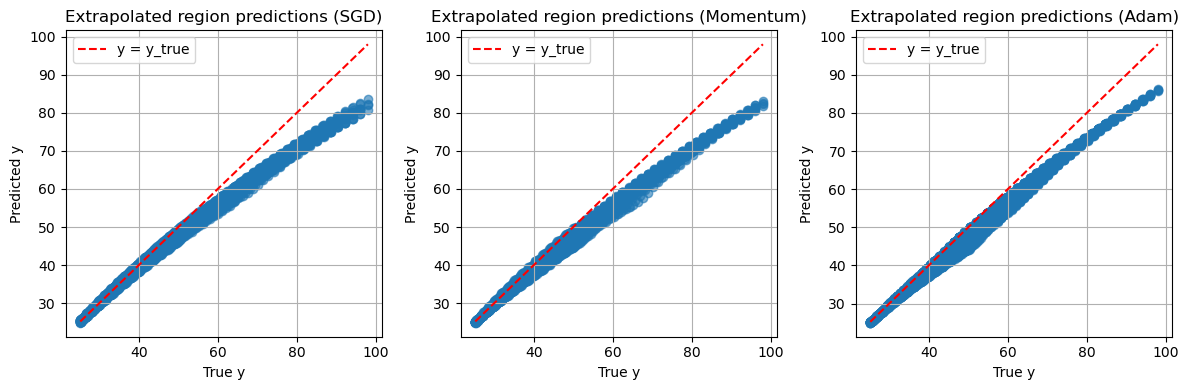

In [44]:


# Identify points outside the original [-5,5] range in any coordinate
mask_extrap = (np.abs(X_extrap[:,0]) > 5) | (np.abs(X_extrap[:,1]) > 5)

X_extra = X_extrap[mask_extrap]
y_true_extra = y_extrap[mask_extrap]
y_sgd_extra = y_pred_extrap_sgd[mask_extrap]
y_mom_extra = y_pred_extrap_mom[mask_extrap]
y_adam_extra = y_pred_extrap_adam[mask_extrap]

# Plot predicted vs true
plt.figure(figsize=(12,4))

for i, (y_pred, label) in enumerate(zip(
        [y_sgd_extra, y_mom_extra, y_adam_extra],
        ["SGD", "Momentum", "Adam"])):
    
    plt.subplot(1,3,i+1)
    plt.scatter(y_true_extra, y_pred, alpha=0.6)
    plt.plot([y_true_extra.min(), y_true_extra.max()],
             [y_true_extra.min(), y_true_extra.max()],
             'r--', label="y = y_true")
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title(f"Extrapolated region predictions ({label})")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Finally, since our function is really z = r<sup>2</sup>, we can graph the true curve and a scatterplot of (r<sup>2</sup>. ,y_pred) for the models

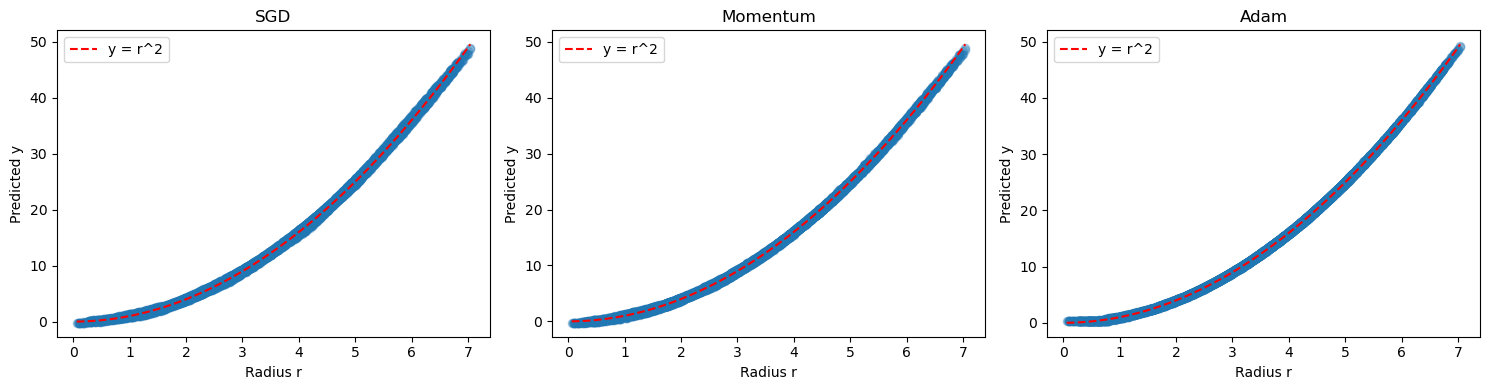

In [47]:


# Compute radius
r = np.sqrt(np.sum(X**2, axis=1))

# Assume you have predictions for each optimizer
pred_sgd = model_sgd.predict(X)
pred_mom = model_momentum.predict(X)
pred_adam = model_adam.predict(X)

preds = [pred_sgd, pred_mom, pred_adam]
titles = ["SGD", "Momentum", "Adam"]

plt.figure(figsize=(15,4))
for i, (pred, title) in enumerate(zip(preds, titles)):
    plt.subplot(1,3,i+1)
    plt.scatter(r, pred, alpha=0.3)
    r_line = np.linspace(r.min(), r.max(), 200)
    y_line = r_line**2
    plt.plot(r_line, y_line, 'r--', label="y = r^2")
    plt.xlabel("Radius r")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.legend()
plt.tight_layout()
plt.show()
